In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
ipl = pd.read_csv(r"C:\Users\DELL\Desktop\ipl score predictor\dataset\ipl_data.csv")

In [4]:
ipl.head()
ipl.info()
ipl.shape
ipl.describe()
ipl.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   bat_team        76014 non-null  object 
 4   bowl_team       76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


mid               0
date              0
venue             0
bat_team          0
bowl_team         0
batsman           0
bowler            0
runs              0
wickets           0
overs             0
runs_last_5       0
wickets_last_5    0
striker           0
non-striker       0
total             0
dtype: int64

In [5]:
ipl.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


In [6]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   bat_team        76014 non-null  object 
 4   bowl_team       76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


In [7]:
ipl.describe()

,mid,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
count,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000
mean,308.627740,74.889349,2.415844,9.783068,33.216434,1.120307,24.962283,8.869287,160.901452
std,178.156878,48.823327,2.015207,5.772587,14.914174,1.053343,20.079752,10.795742,29.246231
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000
25%,154.000000,34.000000,1.000000,4.600000,24.000000,0.000000,10.000000,1.000000,142.000000
50%,308.000000,70.000000,2.000000,9.600000,34.000000,1.000000,20.000000,5.000000,162.000000
75%,463.000000,111.000000,4.000000,14.600000,43.000000,2.000000,35.000000,13.000000,181.000000
max,617.000000,263.000000,10.000000,19.600000,113.000000,7.000000,175.000000,109.000000,263.000000


In [8]:
ipl.isnull().sum()

mid               0
date              0
venue             0
bat_team          0
bowl_team         0
batsman           0
bowler            0
runs              0
wickets           0
overs             0
runs_last_5       0
wickets_last_5    0
striker           0
non-striker       0
total             0
dtype: int64

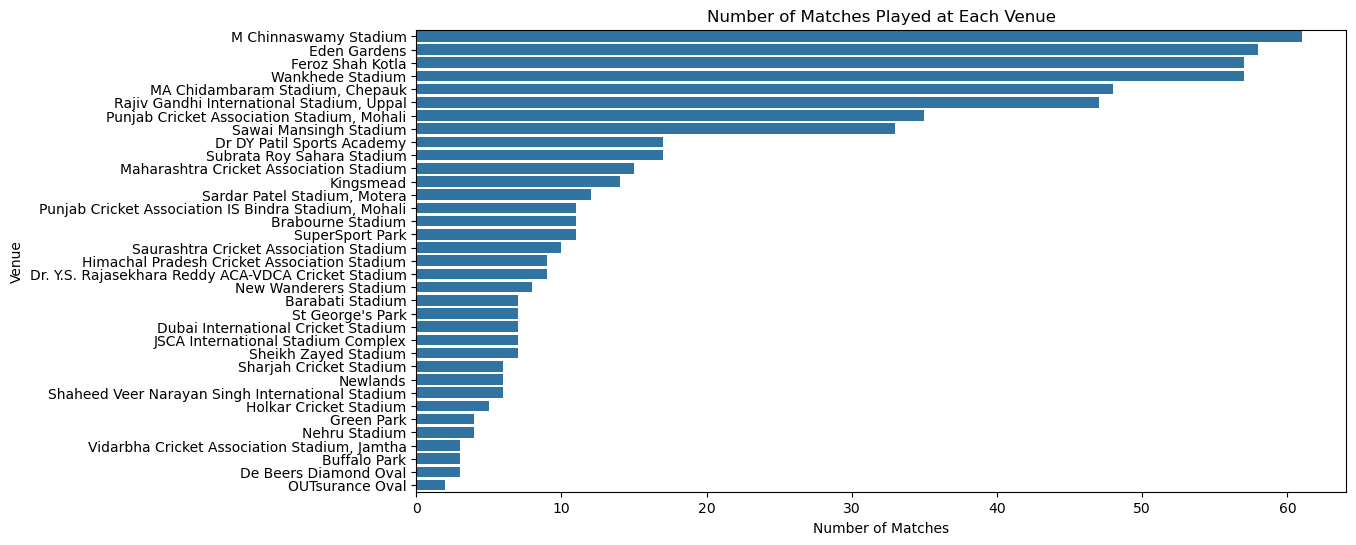

In [9]:
data = ipl.copy()

matches_per_venue = data[['mid', 'venue']].drop_duplicates()
matches_count = matches_per_venue['venue'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(
    x=matches_count.values,
    y=matches_count.index
)

plt.title("Number of Matches Played at Each Venue")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")
plt.show()

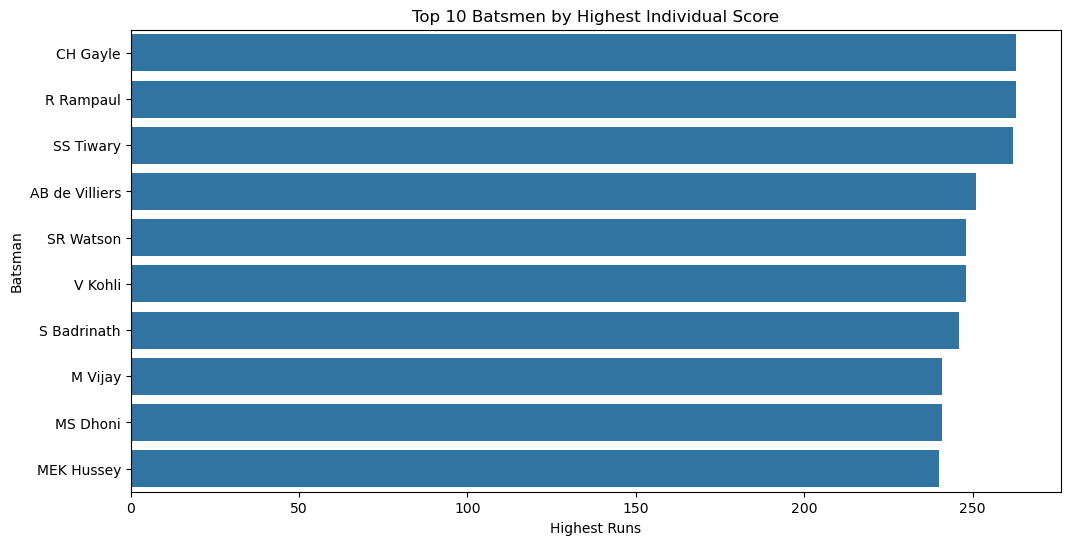

In [10]:
runs_by_batsman = (
    data.groupby('batsman')['runs']
        .max()
        .sort_values(ascending=False)
        .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=runs_by_batsman.values,
    y=runs_by_batsman.index
)

plt.title("Top 10 Batsmen by Highest Individual Score")
plt.xlabel("Highest Runs")
plt.ylabel("Batsman")
plt.show()

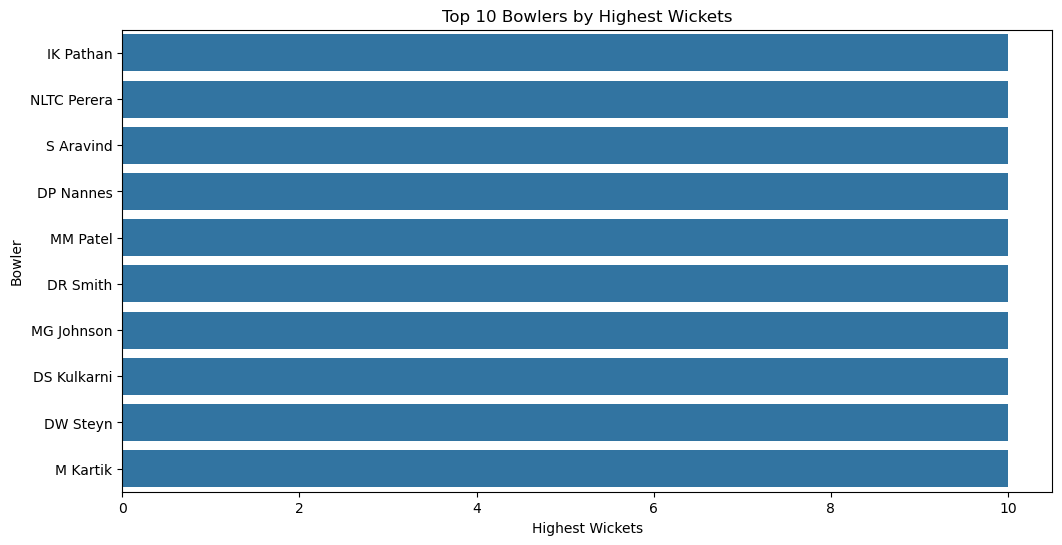

In [11]:
wickets_by_bowler = (
    data.groupby('bowler')['wickets']
        .max()
        .sort_values(ascending=False)
        .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=wickets_by_bowler.values,
    y=wickets_by_bowler.index
)

plt.title("Top 10 Bowlers by Highest Wickets")
plt.xlabel("Highest Wickets")
plt.ylabel("Bowler")
plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['bat_team', 'bowl_team', 'venue', 'batsman', 'bowler']

data_encoded = data.copy()

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    data_encoded[col] = le.fit_transform(data_encoded[col])
    label_encoders[col] = le

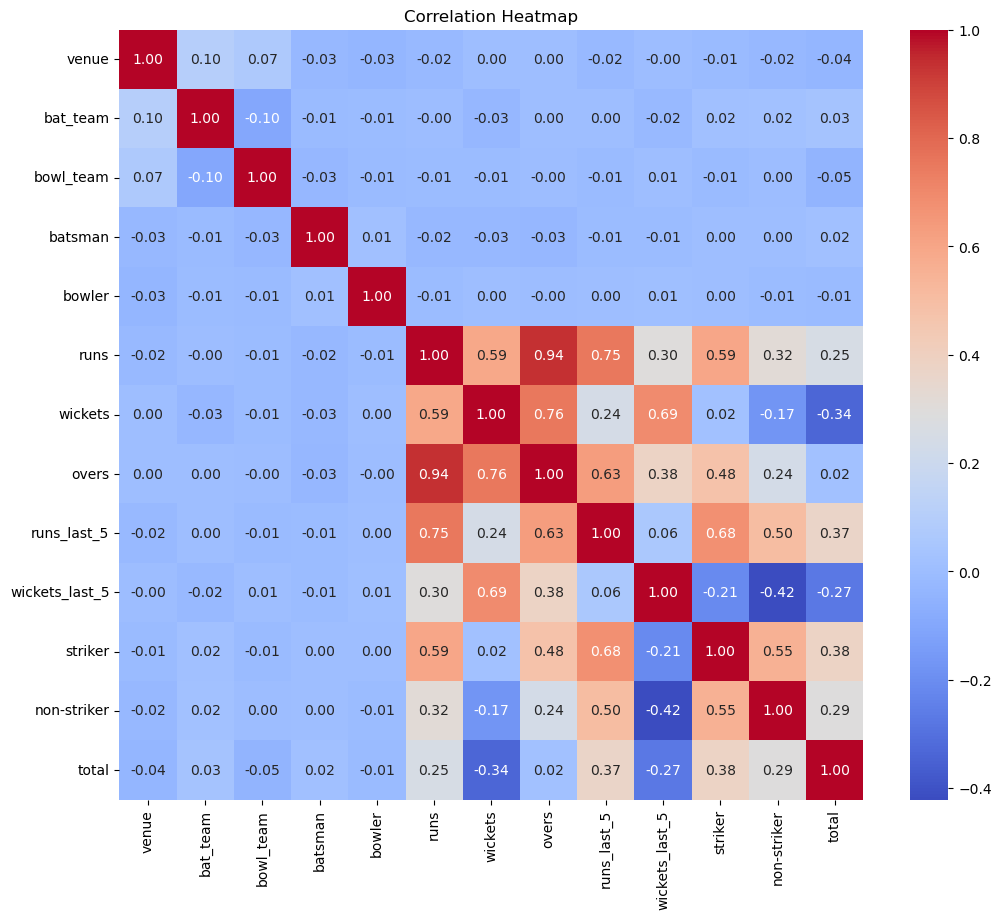

In [13]:
data_corr = data_encoded.drop(columns=["date", "mid"], axis=1)

plt.figure(figsize=(12, 10))

sns.heatmap(
    data_corr.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

feature_cols = [
    'bat_team',
    'bowl_team',
    'venue',
    'runs',
    'wickets',
    'overs',
    'striker',
    'batsman',
    'bowler'
]

X = data_encoded[feature_cols]

y = data_encoded['total']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [16]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (53209, 9)
Testing Features: (22805, 9)
Training Labels: (53209,)
Testing Labels: (22805,)


In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [19]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    
    keras.layers.Dense(512, activation='relu'),
    
    keras.layers.Dense(216, activation='relu'),
    
    keras.layers.Dense(1, activation='linear')
])

huber_loss = tf.keras.losses.Huber(delta=1.0)

model.compile(
    optimizer='adam',
    loss=huber_loss
)

In [20]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 216)            │       110,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           217 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,145 (453.69 KB)

 Trainable params: 116,145 (453.69 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_scaled, y_test)
)

Epoch 1/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 26.6675 - val_loss: 14.8974
Epoch 2/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 14.9399 - val_loss: 14.7014
Epoch 3/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 14.6953 - val_loss: 14.8319
Epoch 4/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 14.6105 - val_loss: 14.0981
Epoch 5/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 14.4538 - val_loss: 14.2281
Epoch 6/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 14.4008 - val_loss: 14.2376
Epoch 7/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 14.3594 - val_loss: 13.8878
Epoch 8/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 14.2855 - val_loss: 13.9421
Epoch 9/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 14.2583 - val_loss: 14.1029
Epoch 10/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 14.2337 - val_loss: 13.9238


In [22]:
from sklearn.metrics import mean_absolute_error

predictions = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mean Absolute Error: 14.414571762084961


In [24]:
model.save("../model/ipl_score_predictor.keras")

In [25]:
import joblib

joblib.dump(scaler, "../model/scaler.pkl")
joblib.dump(label_encoders, "../model/label_encoders.pkl")

['../model/label_encoders.pkl']